## Intermediate Pipeline — Improve Retrieval Quality

Move to **page-level chunking with metadata** (e.g., chapter, section, title), increase retrieval to a **larger `k` (e.g., 6)**, and introduce **reranking with a small `n` (e.g., top 3)**. Metadata helps embeddings disambiguate similar text across different parts of the book (e.g., recurring characters or themes). Increasing `k` improves recall — you’re more likely to retrieve the correct page even if it’s not in the top few results. However, this introduces noise, so reranking is added to refine the candidate set and keep only the most relevant chunks. The small rerank `n` ensures the final context remains focused.  
This setup answers: *“If the right page exists somewhere in the top results, can we reliably surface it and improve answer quality?”*  
This is the practical 80/20 production baseline.

- **Always return answers with citations** to enforce grounding and make evaluation easier.

## RAG Evaluation Metrics

- **Relevance (rule-based)** — atleast one of retrieved chunks are relevant → true/false
- **Groundedness (LLM judge)** — all claims are supported by retrieved context → true/false
- **Answer Correctness (LLM judge)** — answer matches key facts in sample answer → true/false

### Libraries

In [1]:
import pandas as pd
from typing import Any, List
from langchain_community.document_loaders import PyPDFLoader
import pprint
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
import shutil
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
import matplotlib.pyplot as plt
import seaborn as sns
from langchain_classic.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_classic.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage

pd.set_option("display.max_columns", None)

### Benchmark Data

In [2]:
# create benchmark data
benchmark_data = [

    {
        "chat_history": [],
        "question": "What renewed the interest of Machine Learning?",
        "answer": "The incorporation of Google's multilingual neural machine translation system into Google Translate in November 2016 renewed interest in machine learning.",
        "group": "lookup"
    },

    {
        "chat_history": [],
        "question": "What type of features are typically produced through batch processing and stream processing in ML systems?",
        "answer": "Batch processing typically produces static features that change slowly, while stream processing produces dynamic features that change rapidly in real time.",
        "group": "lookup"
    },

    {
        "chat_history": [],
        "question": "What is stratified sampling and why is it used?",
        "answer": "Stratified sampling is a method where the population is divided into groups (strata) and samples are taken from each group separately. It is used to ensure that all important groups are represented in the sample.",
        "group": "lookup"
    },

    {
        "chat_history": [],
        "question": "How do machine learning systems differ from traditional software systems, and what challenges do they introduce?",
        "answer": "Machine learning systems differ from traditional software systems in both how they are built and the challenges they introduce. Traditional software typically relies on explicitly programmed rules and modular separation between code and data, whereas ML systems learn patterns directly from data. This makes ML especially useful for complex tasks such as object detection or language understanding, where manually defining rules would be impractical. Unlike research-focused ML, production ML systems must operate reliably under real-world constraints such as scalability, latency, monitoring, and changing data distributions. As a result, ML systems require specialized tooling for data management, model training, deployment, evaluation, and continuous improvement. Because behavior is driven by both code and learned parameters from data, ML systems are often referred to as Software 2.0.",
        "group": "conceptual"
    },

    {
        "chat_history": [],
        "question": "What is the difference between multiclass and multilabel classification, and what challenges does multilabel classification introduce?",
        "answer": "In multiclass classification, each example belongs to exactly one class, whereas in multilabel classification an example can belong to multiple classes simultaneously. Multilabel problems can be handled either by using multi-hot label representations or by training separate binary classifiers for each class. However, multilabel classification is more challenging because annotation can be inconsistent when annotators disagree on applicable labels, and prediction is harder since the model must determine how many labels to assign rather than selecting just one, making probability interpretation and thresholding more complex.",
        "group": "conceptual"
    },

    {
        "chat_history": [],
        "question": "What is sampling in machine learning, why is it important, and what are its main types?",
        "answer": "Sampling is important in machine learning for managing data size, reducing bias, and improving efficiency. The two main families are nonprobability sampling (e.g., convenience sampling) and random sampling (e.g., reservoir sampling and importance sampling). Effective sampling helps create more representative datasets while optimizing resource usage.",
        "group": "conceptual"
    },

    {
        "chat_history": [],
        "question": "What are the four key requirements of a production ML system, and what does each requirement mean?",
        "answer": "Most ML systems should satisfy four key requirements: reliability, scalability, maintainability, and adaptability. Reliability means the system continues functioning correctly even under failures or adverse conditions. Scalability allows the system to handle growth in data, traffic, and model complexity. Maintainability supports collaboration, reproducibility, and easier debugging through structured workflows and tooling. Adaptability enables the system to evolve as data distributions and business requirements change over time.",
        "group": "long-context"
    },

    {
        "chat_history": [],
        "question": "How do batch processing and stream processing differ, what types of ML features does each support, and why is stream processing important in modern ML systems?",
        "answer": "Batch processing operates on historical data stored in databases, data lakes, or warehouses and typically runs periodically using systems like MapReduce or Spark. It is commonly used to compute slowly changing or static features, such as driver ratings. Stream processing operates on continuously arriving data from systems like Kafka or Kinesis and processes data in real time or near real time using engines such as Apache Flink, KSQL, or Spark Streaming. It is used to compute rapidly changing or dynamic features, such as live demand, available drivers, or recent prices. Stream processing is important because it enables low-latency computation, supports stateful incremental updates without repeatedly recomputing entire datasets, and allows ML systems to react quickly to changing conditions. Modern ML systems often combine both batch and streaming features, requiring infrastructure capable of processing and joining both data types.",
        "group": "long-context"
    },

    {
        "chat_history": [],
        "question": "What factors determine whether an ML feature generalizes well to unseen data, and what trade-offs can arise when designing more generalizable features?",
        "answer": "A feature generalizes well when it remains useful on unseen data instead of only fitting the training data. Important factors include feature coverage and whether feature values are consistent across train and test data. Features that are too specific may improve accuracy on training data but perform poorly on new data.",
        "group": "long-context"
    },

    {
        "chat_history": [],
        "question": "Who is Aristotle?",
        "answer": "I cannot answer this question as it is out of my knowledge.",
        "group": "external"
    },

    {
        "chat_history": [],
        "question": "What is inflation?",
        "answer": "I cannot answer this question as it is out of my knowledge.",
        "group": "external"
    },

    {
        "chat_history": [],
        "question": "Why did the Industrial Revolution lead to urbanization?",
        "answer": "I cannot answer this question as it is out of my knowledge.",
        "group": "external"
    },

    {
        "chat_history": [],
        "question": "wht renewed intrest in machine learning again",
        "answer": "The incorporation of Google's multilingual neural machine translation system into Google Translate in November 2016 renewed interest in machine learning.",
        "group": "rephrase-typo"
    },

    {
        "chat_history": [],
        "question": "wat kinda features come from batch and stream processing usually?",
        "answer": "Batch processing typically produces static features that change slowly, while stream processing produces dynamic features that change rapidly in real time.",
        "group": "rephrase-typo"
    },

    {
        "chat_history": [],
        "question": "why stratified sampeling use by ppl?",
        "answer": "Stratified sampling is a method where the population is divided into groups (strata) and samples are taken from each group separately. It is used to ensure that all important groups are represented in the sample.",
        "group": "rephrase-typo"
    },

    {
        "chat_history": [
            HumanMessage(content="Explain batch processing in ML systems."),
            AIMessage(content="Batch processing operates on historical stored data and usually runs periodically."),

            HumanMessage(content="What about stream processing?"),
            AIMessage(content="Stream processing handles continuously arriving real-time data."),

            HumanMessage(content="Why is stream processing important?"),
            AIMessage(content="It helps ML systems react quickly to changing conditions with low latency.")
        ],
        "question": "What type of features do both usually produce?",
        "answer": "Batch processing typically produces static features that change slowly, while stream processing produces dynamic features that change rapidly in real time.",
        "group": "rephrase-history"
    },

    {
        "chat_history": [
            HumanMessage(content="Why are modern ML systems difficult to maintain?"),
            AIMessage(
                content="ML systems are harder to maintain because they depend on both code and data distributions."),

            HumanMessage(content="What makes debugging difficult?"),
            AIMessage(content="Model behavior can be difficult to interpret and reproduce."),

            HumanMessage(content="Tell me about production ML systems."),
            AIMessage(
                content="Production ML systems need to be designed carefully to work reliably in real-world environments.")
        ],
        "question": "What are the four key requirements for them?",
        "answer": "Most ML systems should satisfy four key requirements: reliability, scalability, maintainability, and adaptability. Reliability means the system continues functioning correctly even under failures or adverse conditions. Scalability allows the system to handle growth in data, traffic, and model complexity. Maintainability supports collaboration, reproducibility, and easier debugging through structured workflows and tooling. Adaptability enables the system to evolve as data distributions and business requirements change over time.",
        "group": "rephrase-history"
    },

    {
        "chat_history": [
            HumanMessage(content="What is regression in machine learning?"),
            AIMessage(content="Regression predicts numerical values for given features."),

            HumanMessage(content="Explain multiclass classification."),
            AIMessage(content="Multiclass classification assigns exactly one class to each example."),

            HumanMessage(content="What about multilabel classification?"),
            AIMessage(content="Multilabel classification allows multiple labels for the same example.")
        ],
        "question": "What challenges does the second classification introduce?",
        "answer": "Multilabel classification introduces challenges because annotation can be inconsistent when annotators disagree on applicable labels, and prediction is harder since the model must determine how many labels to assign rather than selecting just one, making probability interpretation and thresholding more complex.",
        "group": "rephrase-history"
    }
]

# create dataframe for benchmark data
df_benchmark = pd.DataFrame(benchmark_data).reset_index(names="question_id")

df_benchmark

,question_id,chat_history,question,answer,group
0,0,[],What renewed the interest of Machine Learning?,The incorporation of Google's multilingual neu...,lookup
1,1,[],What type of features are typically produced t...,Batch processing typically produces static fea...,lookup
2,2,[],What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup
3,3,[],How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual
4,4,[],What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual
5,5,[],"What is sampling in machine learning, why is i...",Sampling is important in machine learning for ...,conceptual
6,6,[],What are the four key requirements of a produc...,Most ML systems should satisfy four key requir...,long-context
7,7,[],How do batch processing and stream processing ...,Batch processing operates on historical data s...,long-context
8,8,[],What factors determine whether an ML feature g...,A feature generalizes well when it remains use...,long-context
9,9,[],Who is Aristotle?,I cannot answer this question as it is out of ...,external


### Data Loading

In [3]:
file_path = "../data/books/Designing Machine Learning Systems; An Iterative Process for Production.pdf"
loader = PyPDFLoader(file_path)
document = loader.load()

print("\n\nSample page metadata")
pprint.pp(document[100].metadata)

print("\n\n==============\n\n")

print("Sample page content")
print(document[100].page_content)

Ignoring wrong pointing object 25 0 (offset 0)
Ignoring wrong pointing object 38 0 (offset 0)
Ignoring wrong pointing object 134 0 (offset 0)
Ignoring wrong pointing object 249 0 (offset 0)
Ignoring wrong pointing object 407 0 (offset 0)
Ignoring wrong pointing object 447 0 (offset 0)
Ignoring wrong pointing object 1239 0 (offset 0)




Sample page metadata
{'producer': 'macOS Version 15.3.2 (Build 24D81) Quartz PDFContext',
 'creator': 'AH CSS Formatter V7.1 MR2 for Linux64 : 7.1.3.50324 '
            '(2021-04-26T09:47+09)',
 'creationdate': "D:20260428192210Z00'00'",
 'title': 'Designing Machine Learning Systems',
 'author': 'Huyen, Chip;',
 'moddate': "D:20260428192210Z00'00'",
 'source': '../data/books/Designing Machine Learning Systems; An Iterative '
           'Process for Production.pdf',
 'total_pages': 389,
 'page': 100,
 'page_label': '101'}




Sample page content
CHAPTER 4
Training Data
In Chapter 3, we covered how to handle data from the systems perspective. In this
chapter, we’ll go over how to handle data from the data science perspective. Despite
the importance of training data in developing and improving ML models, ML curric!
ula are heavily skewed toward modeling, which is considered by many practitioners
the “fun” part of the process. Building a state-of-the-art model is interesting. Spend!
ing 

### Chunking

In [4]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = text_splitter.split_documents(document)

print(f"Length of chunks: {len(chunks)}")

print("\n\n==============\n\n")

print("Sample chunk")
chunks[100]

Length of chunks: 1158




Sample chunk


Document(metadata={'producer': 'macOS Version 15.3.2 (Build 24D81) Quartz PDFContext', 'creator': 'AH CSS Formatter V7.1 MR2 for Linux64 : 7.1.3.50324 (2021-04-26T09:47+09)', 'creationdate': "D:20260428192210Z00'00'", 'title': 'Designing Machine Learning Systems', 'author': 'Huyen, Chip;', 'moddate': "D:20260428192210Z00'00'", 'source': '../data/books/Designing Machine Learning Systems; An Iterative Process for Production.pdf', 'total_pages': 389, 'page': 33, 'page_label': '34'}, page_content='14It’s not unusual for the ML and data science teams to be among the first to go during a company’s mass\nlayoff, as has been reported at IBM, Uber, Airbnb. See also Sejuti Das’s analysis “How Data Scientists Are Also\nSusceptible to the Layoffs Amid Crisis, ” Analytics India Magazine, May 21, 2020, https://oreil.ly/jobmz.\n15Wikipedia, s.v. “Ensemble learning, ” https://oreil.ly/5qkgp.\nML platform team\nAs the traffic grows, this team has been woken up in the middle of the night\nbecause of pro

### Data Indexing

In [5]:
embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    encode_kwargs={"normalize_embeddings": True},
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [6]:
# vector db path
db_path = "../data/chroma_db"

# remove old db
shutil.rmtree(db_path, ignore_errors=True)

# create vector store
vector_store = Chroma(
    collection_name="ml_book",
    embedding_function=embeddings,
    persist_directory=db_path,
)

# stable ids
ids = [str(i) for i in range(len(chunks))]

# add documents
vector_store.add_documents(
    documents=chunks,
    ids=ids,
)

print(f"length of documents: {len(ids)}")

length of documents: 1158


### Querying

In [7]:
# =========================================================
# pydantic schema
# =========================================================

class RagResponse(BaseModel):
    relevance_check: bool = Field(description="Whether the retrieved chunks are relevant to the question")
    plan: str = Field(description="Short summary of which chunk information supports the answer")
    answer: str = Field(description="Grounded answer with citations")
    groundedness_check: bool = Field(description="Whether every factual claim is supported by the retrieved chunks")
    citation_check: bool = Field(description="Whether all factual claims contain valid citations")
    usefulness_check: bool = Field(description="Whether the answer is clear and useful")

class RephraseQuestion(BaseModel):
    rephrased_question: str = Field(description="Rephrased question")

# =========================================================
# chat history formatter
# =========================================================

def format_chat_history(
    chat_history: List
) -> str:

    if not chat_history:
        return ""

    lines = []

    for message in chat_history:
        if message.type == "human":
            role = "User"
        elif message.type == "ai":
            role = "Assistant"
        else:
            role = message.type.capitalize()

        lines.append(f"{role}: {message.content}")

    return "\n".join(lines)

# =========================================================
# retrieval
# =========================================================

def retrieve_chunks(
    reranker_model: Any,
    question: str,
    vector_store: Any,
    k: int = 3,
    doc_filter: dict[str, Any] | None = None
) -> list[dict[str, Any]]:

    retriever = vector_store.as_retriever(
        search_kwargs={
            "k": k,         
            "filter": doc_filter
        }
    )
    
    compressor = CrossEncoderReranker(model=reranker_model, top_n=3)
    
    compression_retriever = ContextualCompressionRetriever(
        base_compressor=compressor, base_retriever=retriever
    )
    
    results = compression_retriever.invoke(question)

    chunks = []

    for rank, doc in enumerate(results, start=1):

        chunks.append({
            "idx": rank,
            "text": doc.page_content,
            "metadata": doc.metadata,
            "page": doc.metadata["page"]
        })

    return chunks


# =========================================================
# context builder
# =========================================================

def build_context(
    chunks: list[dict[str, Any]]
) -> str:

    context_parts = []

    for chunk in chunks:

        text = (
            f"Chunk idx {chunk['idx']}\n"
            f"Page number {chunk['page']}\n\n"
            f"{chunk['text']}"
        )

        context_parts.append(text)

    context = "\n\n".join(context_parts)

    return context


# =========================================================
# rag pipeline
# =========================================================

def query_engine(
    llm: Any,
    reranker_model: Any,
    question: str,
    vector_store: Any,
    chat_history: List | None = None,
    k: int = 3,
    doc_filter: dict[str, Any] | None = None
) -> dict[str, Any]:

    # -----------------------------------------
    # rephrase question
    # -----------------------------------------

    formatted_chat_history = format_chat_history(chat_history)
    
    try:
        # create structured llm
        rephrase_llm = llm.with_structured_output(RephraseQuestion)
    
        rephrase_prompt = f"""
        Rewrite the latest user question into a concise,
        standalone retrieval question for a RAG system.
        
        Use the conversation history when needed to clarify
        references or missing context.
        
        Return only the rewritten question.
        
        Latest question:
        {question}
        
        Conversation history:
        {formatted_chat_history}
        """
    
        # call llm
        rephrased_question = rephrase_llm.invoke(rephrase_prompt)

        # extract response
        retrieval_question = rephrased_question.rephrased_question
        
    except Exception as e:

        retrieval_question = question
        
    
    # -----------------------------------------
    # retrieve chunks
    # -----------------------------------------

    chunks = retrieve_chunks(
        reranker_model=reranker_model,
        question=retrieval_question,
        vector_store=vector_store,
        k=k,
        doc_filter=doc_filter
    )

    # -----------------------------------------
    # generate answer
    # -----------------------------------------

    context = build_context(chunks)

    prompt = f"""
    Answer the question using ONLY the retrieved chunks.
    
    Question:
    {retrieval_question}
    
    Retrieved chunks:
    {context}
    
    Rules:
    - Use only information from the chunks.
    - Do not use outside knowledge.
    - Do not guess or invent information.
    - If the answer is not in the chunks, say:
      "I do not have enough relevant information in my knowledge to answer this question."
    - Every factual claim must include a citation.
    - Citation format: [chunk_id, p. page_number]
    
    Return ONLY valid JSON:
    
    {{
      "relevance_check": boolean,
      "plan": "short support summary",
      "answer": "string",
      "groundedness_check": boolean,
      "citation_check": boolean,
      "usefulness_check": boolean
    }}
    
    Checks:
    - relevance_check: true when the retrieved chunks are relevant to the question
    - groundedness_check: true when the answer contains no unsupported factual claims; safe refusal answers should also be true
    - citation_check: true when all factual claims include valid citations
    - usefulness_check: true when the answer is clear and useful
    
    Example:
    {{
      "relevance_check": true,
      "plan": "Use refund policy from chunk 2.",
      "answer": "The refund period is 30 days from purchase [2, p. 128].",
      "groundedness_check": true,
      "citation_check": true,
      "usefulness_check": true
    }}
    """

    try:

        # create structured llm
        answer_llm = llm.with_structured_output(RagResponse)

        # call llm
        response = answer_llm.invoke(prompt)

        result = {
            "question": question,
            "formatted_chat_history": formatted_chat_history,
            "retrieval_question": retrieval_question,
            "answer": response.answer,
            "relevance_check": response.relevance_check,
            "plan": response.plan,
            "groundedness_check": response.groundedness_check,
            "citation_check": response.citation_check,
            "usefulness_check": response.usefulness_check,
            "chunks": chunks,
            "context": context,
            "llm_error": None
        }
        
    except Exception as e:

        result = {
            "question": question,
            "formatted_chat_history": formatted_chat_history,
            "retrieval_question": retrieval_question,
            "answer": "Error generating answer",
            "relevance_check": False,
            "plan": "Error generating plan",
            "groundedness_check": False,
            "citation_check": False,
            "usefulness_check": False,
            "chunks": chunks,
            "context": context,
            "llm_error": str(e)
        }

    return result


# =========================================================
# Build dataframe
# =========================================================

# initialize llm
llm = ChatOllama(model="qwen3:1.7b", temperature=0)

# initialize reranker model
reranker_model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-base")

# initialize rows list
rows = []

for row in df_benchmark.itertuples():

    print(f"Answering question {row.Index}...")

    result = query_engine(
        llm=llm,
        reranker_model=reranker_model,
        question=row.question,
        vector_store=vector_store,
        chat_history=row.chat_history,
        k=6,
        doc_filter={
            "title": "Designing Machine Learning Systems"
        }
    )

    rows.append({
        "question_id": row.question_id,
        "question": row.question,
        "ground_truth_answer": row.answer,
        "group": row.group,

        # generated answer
        "formatted_chat_history": result["formatted_chat_history"],
        "retrieval_question": result["retrieval_question"],
        "predicted_answer": result["answer"],
        "relevance_check": result["relevance_check"],
        "plan": result["plan"],
        "groundedness_check": result["groundedness_check"],
        "citation_check": result["citation_check"],
        "usefulness_check": result["usefulness_check"],

        # retrieval
        "context": result["context"],
        "chunks": result["chunks"],
        "llm_error": result["llm_error"],
        "num_chunks": len(result["chunks"])
    })

df_evals = pd.DataFrame(rows)

df_evals

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: BAAI/bge-reranker-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Answering question 0...
Answering question 1...
Answering question 2...
Answering question 3...
Answering question 4...
Answering question 5...
Answering question 6...
Answering question 7...
Answering question 8...
Answering question 9...
Answering question 10...
Answering question 11...
Answering question 12...
Answering question 13...
Answering question 14...
Answering question 15...
Answering question 16...
Answering question 17...


,question_id,question,ground_truth_answer,group,formatted_chat_history,retrieval_question,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks
0,0,What renewed the interest of Machine Learning?,The incorporation of Google's multilingual neu...,lookup,,What factors renewed interest in Machine Learn...,The success of Google's multilingual neural ma...,True,Identify the key factor from the retrieved chu...,True,True,True,"Chunk idx 1\nPage number 20\n\n1Mike Schuster,...","[{'idx': 1, 'text': '1Mike Schuster, Melvin Jo...",None,3
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,,What types of features are commonly generated ...,Batch processing generates static features (e....,True,Identify batch and stream processing feature t...,True,True,True,Chunk idx 1\nPage number 97\n\nas drivers’ rat...,"[{'idx': 1, 'text': 'as drivers’ ratings (if a...",None,3
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,,What is stratified sampling and why is it used?,Stratified sampling divides the population int...,True,Stratified sampling involves dividing the popu...,True,True,True,"Chunk idx 1\nPage number 103\n\nyour data, sam...","[{'idx': 1, 'text': 'your data, samples of thi...",None,3
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,,What are the key differences between machine l...,Machine learning systems differ from tradition...,True,Summarize key differences and challenges betwe...,True,True,True,"Chunk idx 1\nPage number 41\n\n31Xinyun Chen, ...","[{'idx': 1, 'text': '31Xinyun Chen, Chang Liu,...",None,3
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,,What is the difference between multiclass and ...,Multiclass classification involves examples be...,True,Compare multiclass and multilabel classificati...,True,True,True,Chunk idx 1\nPage number 57\n\nclass. When an ...,"[{'idx': 1, 'text': 'class. When an example ca...",None,3
5,5,"What is sampling in machine learning, why is i...",Sampling is important in machine learning for ...,conceptual,,"What is sampling in machine learning, and why ...",Sampling in machine learning refers to selecti...,True,Sampling in machine learning involves methods ...,True,True,True,Chunk idx 1\nPage number 106\n\nThis means tha...,"[{'idx': 1, 'text': 'This means that each inco...",None,3
6,6,What are the four key requirements of a produc...,Most ML systems should satisfy four key requir...,long-context,,What are the four key requirements for a produ...,The four key requirements for a production ML ...,True,List the four requirements and their entailmen...,True,True,True,Chunk idx 1\nPage number 48\n\nFigure 2-1. How...,"[{'idx': 1, 'text': 'Figure 2-1. How long it t...",None,3
7,7,How do batch processing and stream processing ...,Batch processing operates on historical data s...,long-context,,What is the difference between batch processin...,Batch processing involves periodic computation...,True,Compare batch and stream processing difference...,True,True,True,Chunk idx 1\nPage number 97\n\ntwo reasons. Fi...,"[{'idx': 1, 'text': 'two reasons. First, strea...",None,3
8,8,What factors determine whether an ML feature g...,A feature generalizes well when it remains use...,long-context,,What factors determine the generalization of M...,The generalization of ML features to unseen da...,True,Identify factors and trade-offs related to fea...,True,True,True,Chunk idx 1\nPage number 163\n\nFeature import...,"[{'idx': 1, 'text': 'Feature importance is in ...",None,3
9,9,Who is Aristotle?,I cannot answer this question as it is out of ...,external,,Who is Aristotle?,I do not have enough relevant information in m...,False,No relevant chunks provided about Aristotle.,False,False,False,Chunk idx 1\

### Evaluation

In [8]:
# initialize llm
llm = ChatOllama(model="qwen3:1.7b", temperature=0)

In [9]:
class JudgeResult(BaseModel):
    think: str = Field(description="Short reasoning used to decide the evaluation result")
    flag: bool = Field(description="True if the evaluation passes, otherwise False")
    reason: str = Field(description="Brief explanation for the final decision")

In [10]:
def check_rephrase(row) -> JudgeResult:

    print(f"Evaluating retrieval question for row {row.name}...")

    question = row["question"]
    retrieval_question = row["retrieval_question"]
    formatted_chat_history = row["formatted_chat_history"]

    prompt = f"""
    You are judging whether a rewritten question is a good
    standalone retrieval question.
    
    Original question:
    {question}
    
    Conversation history:
    {formatted_chat_history}
    
    Rewritten question:
    {retrieval_question}
    
    Set flag=True if the rewritten question:
    - preserves the original meaning,
    - correctly uses conversation history when needed,
    - is clear, concise, and retrieval-friendly,
    - or correctly keeps the original question unchanged if it is already clear.
    
    Set flag=False if the rewritten question:
    - changes the meaning,
    - adds unsupported assumptions,
    - drops important context,
    - becomes vague, misleading, or incorrect.
    
    Do not use outside knowledge.
    
    Return ONLY valid JSON:
    {{
      "think": "Short reasoning",
      "flag": <true_or_false>,
      "reason": "Brief reason"
    }}
    """

    structured_llm = llm.with_structured_output(JudgeResult)

    response = structured_llm.invoke(prompt)

    return response

# check retrieval
rephrase_results = df_evals.apply(check_rephrase, axis=1)
df_evals["rephrase_think"] = rephrase_results.apply(lambda x: x.think)
df_evals["rephrase_flag"] = rephrase_results.apply(lambda x: x.flag)
df_evals["rephrase_reason"] = rephrase_results.apply(lambda x: x.reason)

df_evals.head()

Evaluating retrieval question for row 0...
Evaluating retrieval question for row 1...
Evaluating retrieval question for row 2...
Evaluating retrieval question for row 3...
Evaluating retrieval question for row 4...
Evaluating retrieval question for row 5...
Evaluating retrieval question for row 6...
Evaluating retrieval question for row 7...
Evaluating retrieval question for row 8...
Evaluating retrieval question for row 9...
Evaluating retrieval question for row 10...
Evaluating retrieval question for row 11...
Evaluating retrieval question for row 12...
Evaluating retrieval question for row 13...
Evaluating retrieval question for row 14...
Evaluating retrieval question for row 15...
Evaluating retrieval question for row 16...
Evaluating retrieval question for row 17...


,question_id,question,ground_truth_answer,group,formatted_chat_history,retrieval_question,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks,rephrase_think,rephrase_flag,rephrase_reason
0,0,What renewed the interest of Machine Learning?,The incorporation of Google's multilingual neu...,lookup,,What factors renewed interest in Machine Learn...,The success of Google's multilingual neural ma...,True,Identify the key factor from the retrieved chu...,True,True,True,"Chunk idx 1\nPage number 20\n\n1Mike Schuster,...","[{'idx': 1, 'text': '1Mike Schuster, Melvin Jo...",None,3,The rewritten question uses 'factors' which is...,True,The rewritten question preserves the original ...
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,,What types of features are commonly generated ...,Batch processing generates static features (e....,True,Identify batch and stream processing feature t...,True,True,True,Chunk idx 1\nPage number 97\n\nas drivers’ rat...,"[{'idx': 1, 'text': 'as drivers’ ratings (if a...",None,3,The rewritten question uses 'commonly generate...,True,The meaning is preserved as the key informatio...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,,What is stratified sampling and why is it used?,Stratified sampling divides the population int...,True,Stratified sampling involves dividing the popu...,True,True,True,"Chunk idx 1\nPage number 103\n\nyour data, sam...","[{'idx': 1, 'text': 'your data, samples of thi...",None,3,The rewritten question is exactly the same as ...,True,The rewritten question matches the original in...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,,What are the key differences between machine l...,Machine learning systems differ from tradition...,True,Summarize key differences and challenges betwe...,True,True,True,"Chunk idx 1\nPage number 41\n\n31Xinyun Chen, ...","[{'idx': 1, 'text': '31Xinyun Chen, Chang Liu,...",None,3,The rewritten question preserves the original ...,True,The rewritten question maintains the original ...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,,What is the difference between multiclass and ...,Multiclass classification involves examples be...,True,Compare multiclass and multilabel classificati...,True,True,True,Chunk idx 1\nPage number 57\n\nclass. When an ...,"[{'idx': 1, 'text': 'class. When an example ca...",None,3,The rewritten question is identical to the ori...,True,The rewritten question matches the original ex...


In [11]:
def check_relevance(row) -> JudgeResult:

    print(f"Evaluating relevance for question {row.name}...")
    
    question = row["question"]
    context = row["context"]  
    
    prompt = f"""
    You are judging retrieval relevance for a RAG system.
    
    Question:
    {question}
    
    Retrieved context:
    {context}

    Set flag=True only if atleast one of the retrieved chunks in context contains enough relevant and specific information to answer most or all important parts of the question.
    
    Set flag=False if the context:
    - all chunks are irrelevant to the question,
    - all chunks miss major information needed to answer the question.

    Do not use outside knowledge.
    Judge relevance only based on the retrieved context and the question.
    
    Return ONLY valid JSON:
    {{
      "think": "Short reasoning about whether the retrieved context is sufficiently relevant and informative",
      "flag": <true_or_false>,
      "reason": "Brief reason"
    }}
    """

    # initialize structure llm with pydantic schema
    structured_llm = llm.with_structured_output(JudgeResult)

    # call llm
    response = structured_llm.invoke(prompt)

    return response

# check relevance 
relevance_results = df_evals.apply(check_relevance, axis=1)
df_evals["relevance_think"] = relevance_results.apply(lambda x: x.think)
df_evals["relevance_flag"] = relevance_results.apply(lambda x: x.flag)
df_evals["relevance_reason"] = relevance_results.apply(lambda x: x.reason)

df_evals.head()

Evaluating relevance for question 0...
Evaluating relevance for question 1...
Evaluating relevance for question 2...
Evaluating relevance for question 3...
Evaluating relevance for question 4...
Evaluating relevance for question 5...
Evaluating relevance for question 6...
Evaluating relevance for question 7...
Evaluating relevance for question 8...
Evaluating relevance for question 9...
Evaluating relevance for question 10...
Evaluating relevance for question 11...
Evaluating relevance for question 12...
Evaluating relevance for question 13...
Evaluating relevance for question 14...
Evaluating relevance for question 15...
Evaluating relevance for question 16...
Evaluating relevance for question 17...


,question_id,question,ground_truth_answer,group,formatted_chat_history,retrieval_question,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks,rephrase_think,rephrase_flag,rephrase_reason,relevance_think,relevance_flag,relevance_reason
0,0,What renewed the interest of Machine Learning?,The incorporation of Google's multilingual neu...,lookup,,What factors renewed interest in Machine Learn...,The success of Google's multilingual neural ma...,True,Identify the key factor from the retrieved chu...,True,True,True,"Chunk idx 1\nPage number 20\n\n1Mike Schuster,...","[{'idx': 1, 'text': '1Mike Schuster, Melvin Jo...",None,3,The rewritten question uses 'factors' which is...,True,The rewritten question preserves the original ...,The first chunk directly addresses the event t...,True,Chunk 1 provides the specific answer to the qu...
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,,What types of features are commonly generated ...,Batch processing generates static features (e....,True,Identify batch and stream processing feature t...,True,True,True,Chunk idx 1\nPage number 97\n\nas drivers’ rat...,"[{'idx': 1, 'text': 'as drivers’ ratings (if a...",None,3,The rewritten question uses 'commonly generate...,True,The meaning is preserved as the key informatio...,The retrieved context includes information abo...,True,Chunks 1 and 2 provide relevant and specific i...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,,What is stratified sampling and why is it used?,Stratified sampling divides the population int...,True,Stratified sampling involves dividing the popu...,True,True,True,"Chunk idx 1\nPage number 103\n\nyour data, sam...","[{'idx': 1, 'text': 'your data, samples of thi...",None,3,The rewritten question is exactly the same as ...,True,The rewritten question matches the original in...,Chunk idx 1 directly addresses stratified samp...,True,Chunk idx 1 explicitly explains stratified sam...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,,What are the key differences between machine l...,Machine learning systems differ from tradition...,True,Summarize key differences and challenges betwe...,True,True,True,"Chunk idx 1\nPage number 41\n\n31Xinyun Chen, ...","[{'idx': 1, 'text': '31Xinyun Chen, Chang Liu,...",None,3,The rewritten question preserves the original ...,True,The rewritten question maintains the original ...,The retrieved context discusses the unique cha...,True,All chunks are relevant and provide necessary ...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,,What is the difference between multiclass and ...,Multiclass classification involves examples be...,True,Compare multiclass and multilabel classificati...,True,True,True,Chunk idx 1\nPage number 57\n\nclass. When an ...,"[{'idx': 1, 'text': 'class. When an example ca...",None,3,The rewritten question is identical to the ori...,True,The rewritten question matches the original ex...,The retrieved context discusses the difference...,True,The context provides sufficient information to...


In [12]:
def check_groundedness(row) -> JudgeResult:

    print(f"Evaluating groundedness for question {row.name}...")
    
    question = row["question"]
    predicted_answer = row["predicted_answer"]
    context = row["context"]  

    prompt = f"""
    Judge if the predicted answer is fully cited and grounded in the retrieved context.
    
    Question:
    {question}
    
    Retrieved context:
    {context}
    
    Predicted answer:
    {predicted_answer}

    Set flag=True if:
    - the answer is a safe refusal or error message, OR
    - every factual claim has a citation and is supported by the retrieved context.
    
    Set flag=False if the predicted answer:
    - contains any factual claim that is missing a citation,
    - is unsupported or partially supported by the retrieved context,
    - contradicts the retrieved context,
    - or uses outside knowledge.
    
    Judge only the predicted answer. Do not penalize missing facts from the context.
    
    Return ONLY valid JSON:
    {{
      "think": "Brief support check",
      "flag": <true_or_false>,
      "reason": "Brief reason"
    }}
    """

    # initialize structure llm with pydantic schema
    structured_llm = llm.with_structured_output(JudgeResult)

    # call llm
    response = structured_llm.invoke(prompt)

    return response

# check groundedness
groundedness_results = df_evals.apply(check_groundedness, axis=1)
df_evals["groundedness_think"] = groundedness_results.apply(lambda x: x.think)
df_evals["groundedness_flag"] = groundedness_results.apply(lambda x: x.flag)
df_evals["groundedness_reason"] = groundedness_results.apply(lambda x: x.reason)

df_evals.head()

Evaluating groundedness for question 0...
Evaluating groundedness for question 1...
Evaluating groundedness for question 2...
Evaluating groundedness for question 3...
Evaluating groundedness for question 4...
Evaluating groundedness for question 5...
Evaluating groundedness for question 6...
Evaluating groundedness for question 7...
Evaluating groundedness for question 8...
Evaluating groundedness for question 9...
Evaluating groundedness for question 10...
Evaluating groundedness for question 11...
Evaluating groundedness for question 12...
Evaluating groundedness for question 13...
Evaluating groundedness for question 14...
Evaluating groundedness for question 15...
Evaluating groundedness for question 16...
Evaluating groundedness for question 17...


,question_id,question,ground_truth_answer,group,formatted_chat_history,retrieval_question,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks,rephrase_think,rephrase_flag,rephrase_reason,relevance_think,relevance_flag,relevance_reason,groundedness_think,groundedness_flag,groundedness_reason
0,0,What renewed the interest of Machine Learning?,The incorporation of Google's multilingual neu...,lookup,,What factors renewed interest in Machine Learn...,The success of Google's multilingual neural ma...,True,Identify the key factor from the retrieved chu...,True,True,True,"Chunk idx 1\nPage number 20\n\n1Mike Schuster,...","[{'idx': 1, 'text': '1Mike Schuster, Melvin Jo...",None,3,The rewritten question uses 'factors' which is...,True,The rewritten question preserves the original ...,The first chunk directly addresses the event t...,True,Chunk 1 provides the specific answer to the qu...,The predicted answer cites the specific source...,True,"The answer is fully cited with [1, p. 20] and ..."
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,,What types of features are commonly generated ...,Batch processing generates static features (e....,True,Identify batch and stream processing feature t...,True,True,True,Chunk idx 1\nPage number 97\n\nas drivers’ rat...,"[{'idx': 1, 'text': 'as drivers’ ratings (if a...",None,3,The rewritten question uses 'commonly generate...,True,The meaning is preserved as the key informatio...,The retrieved context includes information abo...,True,Chunks 1 and 2 provide relevant and specific i...,The predicted answer cites the retrieved conte...,True,All factual claims are supported by the retrie...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,,What is stratified sampling and why is it used?,Stratified sampling divides the population int...,True,Stratified sampling involves dividing the popu...,True,True,True,"Chunk idx 1\nPage number 103\n\nyour data, sam...","[{'idx': 1, 'text': 'your data, samples of thi...",None,3,The rewritten question is exactly the same as ...,True,The rewritten question matches the original in...,Chunk idx 1 directly addresses stratified samp...,True,Chunk idx 1 explicitly explains stratified sam...,The predicted answer correctly cites the conte...,True,The answer is fully cited and grounded in the ...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,,What are the key differences between machine l...,Machine learning systems differ from tradition...,True,Summarize key differences and challenges betwe...,True,True,True,"Chunk idx 1\nPage number 41\n\n31Xinyun Chen, ...","[{'idx': 1, 'text': '31Xinyun Chen, Chang Liu,...",None,3,The rewritten question preserves the original ...,True,The rewritten question maintains the original ...,The retrieved context discusses the unique cha...,True,All chunks are relevant and provide necessary ...,The predicted answer lists three key differenc...,True,All factual claims in the predicted answer are...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,,What is the difference between multiclass and ...,Multiclass classification involves examples be...,True,Compare multiclass and multilabel classificati...,True,True,True,Chunk idx 1\nPage number 57\n\nclass. When an ...,"[{'idx': 1, 'text': 'class. When an example ca...",None,3,The rewritten question is identical to the ori...,True,The rewritten question matches the original ex...,The retrieved context discusses the difference...,True,The context provides sufficient information to...,The predicted answer correctly identifies the ...,True,The answer is fully cited and grounded in the ...


In [13]:
def check_correctness(row) -> JudgeResult:

    print(f"Evaluating correctness for question {row.name}...")
    
    question = row["question"]
    ground_truth_answer = row["ground_truth_answer"]
    predicted_answer = row["predicted_answer"]

    prompt = f"""
    You are judging answer correctness for a RAG system.
    
    Question:
    {question}
    
    Predicted answer:
    {predicted_answer}
    
    Ground truth answer:
    {ground_truth_answer}

    Set flag=True only if the predicted answer is factually consistent with the ground truth and covers the main expected points, even if wording differs.
    
    Set flag=False if the predicted answer:
    - contradicts the ground truth,
    - misses important information,
    - contains incorrect or misleading claims,
    - or is too vague to properly answer the question.

    Do not use outside knowledge.
    Judge correctness only by comparing the predicted answer against the ground truth answer.
    
    Return ONLY valid JSON:
    {{
      "think": "Short reasoning about how well the predicted answer matches the ground truth",
      "flag": <true_or_false>,
      "reason": "Brief reason"
    }}
    """

    # initialize structure llm with pydantic schema
    structured_llm = llm.with_structured_output(JudgeResult)

    # call llm
    response = structured_llm.invoke(prompt)

    return response


# check correctness
correctness_results = df_evals.apply(check_correctness, axis=1)
df_evals["correctness_think"] = correctness_results.apply(lambda x: x.think)
df_evals["correctness_flag"] = correctness_results.apply(lambda x: x.flag)
df_evals["correctness_reason"] = correctness_results.apply(lambda x: x.reason)

df_evals.head()

Evaluating correctness for question 0...
Evaluating correctness for question 1...
Evaluating correctness for question 2...
Evaluating correctness for question 3...
Evaluating correctness for question 4...
Evaluating correctness for question 5...
Evaluating correctness for question 6...
Evaluating correctness for question 7...
Evaluating correctness for question 8...
Evaluating correctness for question 9...
Evaluating correctness for question 10...
Evaluating correctness for question 11...
Evaluating correctness for question 12...
Evaluating correctness for question 13...
Evaluating correctness for question 14...
Evaluating correctness for question 15...
Evaluating correctness for question 16...
Evaluating correctness for question 17...


,question_id,question,ground_truth_answer,group,formatted_chat_history,retrieval_question,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks,rephrase_think,rephrase_flag,rephrase_reason,relevance_think,relevance_flag,relevance_reason,groundedness_think,groundedness_flag,groundedness_reason,correctness_think,correctness_flag,correctness_reason
0,0,What renewed the interest of Machine Learning?,The incorporation of Google's multilingual neu...,lookup,,What factors renewed interest in Machine Learn...,The success of Google's multilingual neural ma...,True,Identify the key factor from the retrieved chu...,True,True,True,"Chunk idx 1\nPage number 20\n\n1Mike Schuster,...","[{'idx': 1, 'text': '1Mike Schuster, Melvin Jo...",None,3,The rewritten question uses 'factors' which is...,True,The rewritten question preserves the original ...,The first chunk directly addresses the event t...,True,Chunk 1 provides the specific answer to the qu...,The predicted answer cites the specific source...,True,"The answer is fully cited with [1, p. 20] and ...",The predicted answer correctly identifies the ...,True,The predicted answer is factually consistent w...
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,,What types of features are commonly generated ...,Batch processing generates static features (e....,True,Identify batch and stream processing feature t...,True,True,True,Chunk idx 1\nPage number 97\n\nas drivers’ rat...,"[{'idx': 1, 'text': 'as drivers’ ratings (if a...",None,3,The rewritten question uses 'commonly generate...,True,The meaning is preserved as the key informatio...,The retrieved context includes information abo...,True,Chunks 1 and 2 provide relevant and specific i...,The predicted answer cites the retrieved conte...,True,All factual claims are supported by the retrie...,The predicted answer accurately captures the e...,True,The predicted answer aligns with the ground tr...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,,What is stratified sampling and why is it used?,Stratified sampling divides the population int...,True,Stratified sampling involves dividing the popu...,True,True,True,"Chunk idx 1\nPage number 103\n\nyour data, sam...","[{'idx': 1, 'text': 'your data, samples of thi...",None,3,The rewritten question is exactly the same as ...,True,The rewritten question matches the original in...,Chunk idx 1 directly addresses stratified samp...,True,Chunk idx 1 explicitly explains stratified sam...,The predicted answer correctly cites the conte...,True,The answer is fully cited and grounded in the ...,The predicted answer correctly describes strat...,False,The predicted answer misses the key purpose of...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,,What are the key differences between machine l...,Machine learning systems differ from tradition...,True,Summarize key differences and challenges betwe...,True,True,True,"Chunk idx 1\nPage number 41\n\n31Xinyun Chen, ...","[{'idx': 1, 'text': '31Xinyun Chen, Chang Liu,...",None,3,The rewritten question preserves the original ...,True,The rewritten question maintains the original ...,The retrieved context discusses the unique cha...,True,All chunks are relevant and provide necessary ...,The predicted answer lists three key differenc...,True,All factual claims in the predicted answer are...,The predicted answer correctly identifies the ...,True,The predicted answer aligns with the ground tr...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,,What is the difference between multiclass and ...,Multiclass classification involves examples be...,True,Compare multiclass and multilabel classificati...,True,True,True,Chunk idx 1\nPage number 57\n\nclass. When 

### Performance Check

In [14]:
df_evals

,question_id,question,ground_truth_answer,group,formatted_chat_history,retrieval_question,predicted_answer,relevance_check,plan,groundedness_check,citation_check,usefulness_check,context,chunks,llm_error,num_chunks,rephrase_think,rephrase_flag,rephrase_reason,relevance_think,relevance_flag,relevance_reason,groundedness_think,groundedness_flag,groundedness_reason,correctness_think,correctness_flag,correctness_reason
0,0,What renewed the interest of Machine Learning?,The incorporation of Google's multilingual neu...,lookup,,What factors renewed interest in Machine Learn...,The success of Google's multilingual neural ma...,True,Identify the key factor from the retrieved chu...,True,True,True,"Chunk idx 1\nPage number 20\n\n1Mike Schuster,...","[{'idx': 1, 'text': '1Mike Schuster, Melvin Jo...",None,3,The rewritten question uses 'factors' which is...,True,The rewritten question preserves the original ...,The first chunk directly addresses the event t...,True,Chunk 1 provides the specific answer to the qu...,The predicted answer cites the specific source...,True,"The answer is fully cited with [1, p. 20] and ...",The predicted answer correctly identifies the ...,True,The predicted answer is factually consistent w...
1,1,What type of features are typically produced t...,Batch processing typically produces static fea...,lookup,,What types of features are commonly generated ...,Batch processing generates static features (e....,True,Identify batch and stream processing feature t...,True,True,True,Chunk idx 1\nPage number 97\n\nas drivers’ rat...,"[{'idx': 1, 'text': 'as drivers’ ratings (if a...",None,3,The rewritten question uses 'commonly generate...,True,The meaning is preserved as the key informatio...,The retrieved context includes information abo...,True,Chunks 1 and 2 provide relevant and specific i...,The predicted answer cites the retrieved conte...,True,All factual claims are supported by the retrie...,The predicted answer accurately captures the e...,True,The predicted answer aligns with the ground tr...
2,2,What is stratified sampling and why is it used?,Stratified sampling is a method where the popu...,lookup,,What is stratified sampling and why is it used?,Stratified sampling divides the population int...,True,Stratified sampling involves dividing the popu...,True,True,True,"Chunk idx 1\nPage number 103\n\nyour data, sam...","[{'idx': 1, 'text': 'your data, samples of thi...",None,3,The rewritten question is exactly the same as ...,True,The rewritten question matches the original in...,Chunk idx 1 directly addresses stratified samp...,True,Chunk idx 1 explicitly explains stratified sam...,The predicted answer correctly cites the conte...,True,The answer is fully cited and grounded in the ...,The predicted answer correctly describes strat...,False,The predicted answer misses the key purpose of...
3,3,How do machine learning systems differ from tr...,Machine learning systems differ from tradition...,conceptual,,What are the key differences between machine l...,Machine learning systems differ from tradition...,True,Summarize key differences and challenges betwe...,True,True,True,"Chunk idx 1\nPage number 41\n\n31Xinyun Chen, ...","[{'idx': 1, 'text': '31Xinyun Chen, Chang Liu,...",None,3,The rewritten question preserves the original ...,True,The rewritten question maintains the original ...,The retrieved context discusses the unique cha...,True,All chunks are relevant and provide necessary ...,The predicted answer lists three key differenc...,True,All factual claims in the predicted answer are...,The predicted answer correctly identifies the ...,True,The predicted answer aligns with the ground tr...
4,4,What is the difference between multiclass and ...,"In multiclass classification, each example bel...",conceptual,,What is the difference between multiclass and ...,Multiclass classification involves examples be...,True,Compare multiclass and multilabel classificati...,True,True,True,Chunk idx 1\nPage number 57\n\nclass. When 

In [15]:
# create metrics
df_metrics = (
    df_evals[['rephrase_flag', 'relevance_flag', 'groundedness_flag', 'correctness_flag']]
    .mean() * 100
).reset_index()

# rename cols
df_metrics.columns = ["metric", "value"]

df_metrics

,metric,value
0,rephrase_flag,88.888889
1,relevance_flag,77.777778
2,groundedness_flag,100.000000
3,correctness_flag,88.888889


In [16]:
# create group level metrics
df_group_metrics = (
    df_evals[['rephrase_flag', 'relevance_flag', 'groundedness_flag', 'correctness_flag', 'group']]
    .groupby(['group'])
    .mean()
    .reset_index()
)

# melt the df
df_group_metrics = df_group_metrics.melt(id_vars='group', var_name='metric', value_name='proportion')

# make score a percentage
df_group_metrics['percentage'] = df_group_metrics['proportion'] * 100

df_group_metrics

,group,metric,proportion,percentage
0,conceptual,rephrase_flag,0.666667,66.666667
1,external,rephrase_flag,1.000000,100.000000
2,long-context,rephrase_flag,1.000000,100.000000
3,lookup,rephrase_flag,1.000000,100.000000
4,rephrase-history,rephrase_flag,1.000000,100.000000
5,rephrase-typo,rephrase_flag,0.666667,66.666667
6,conceptual,relevance_flag,1.000000,100.000000
7,external,relevance_flag,0.000000,0.000000
8,long-context,relevance_flag,1.000000,100.000000
9,lookup,relevance_flag,1.000000,100.000000


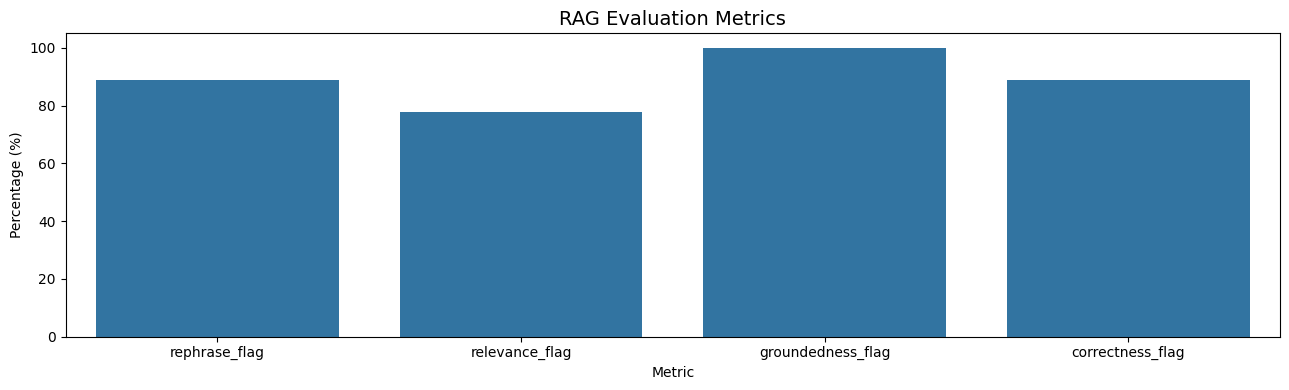

In [17]:
# Plot
fig, ax = plt.subplots(figsize=(13, 4))

sns.barplot(
    data=df_metrics,
    x="metric",
    y="value",
    ax=ax
)

# Formatting
ax.set_title("RAG Evaluation Metrics", fontsize=14)
ax.set_xlabel("Metric")
ax.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

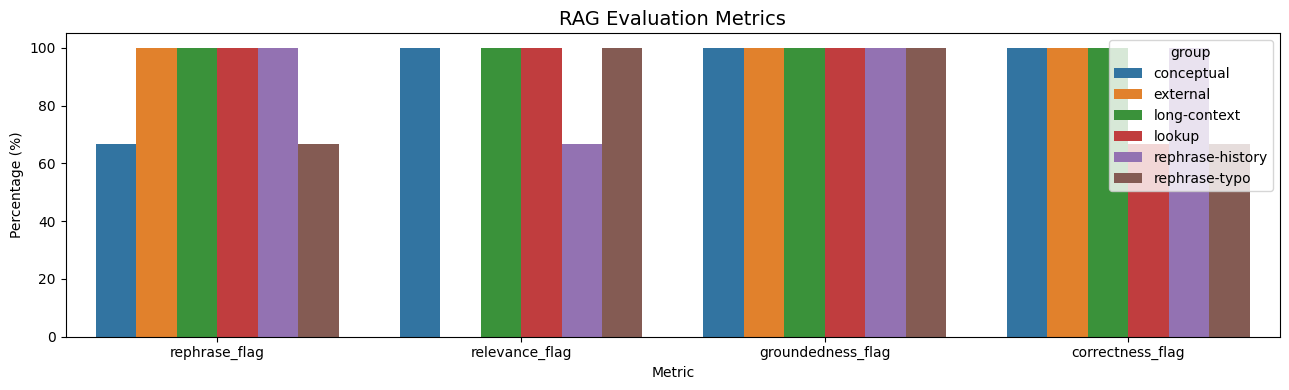

In [18]:
# Plot
fig, ax = plt.subplots(figsize=(13, 4))

sns.barplot(
    data=df_group_metrics,
    x="metric",
    y="percentage",
    hue='group',
    ax=ax
)

# Formatting
ax.set_title("RAG Evaluation Metrics", fontsize=14)
ax.set_xlabel("Metric")
ax.set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

### Failure Analysis

In [19]:
def view_result(
    df_evals: pd.DataFrame,
    question_id: int
) -> None:

    # filter row
    row = df_evals[
        df_evals["question_id"] == question_id
    ].iloc[0]

    # =====================================================
    # question
    # =====================================================

    print("=" * 80)
    print("QUESTION")
    print("=" * 80)

    print(row["question"])

    # =====================================================
    # group
    # =====================================================

    print("\n" + "=" * 80)
    print("GROUP")
    print("=" * 80)

    print(row["group"])
    
    # =====================================================
    # chat history
    # =====================================================
    
    print("\n" + "=" * 80)
    print("CHAT HISTORY")
    print("=" * 80)
    
    print(row["formatted_chat_history"])

    # =====================================================
    # retrieval question
    # =====================================================
    
    print("\n" + "=" * 80)
    print("RETRIEVAL QUESTION")
    print("=" * 80)
    
    print(row["retrieval_question"])

    # =====================================================
    # ground truth
    # =====================================================

    print("\n" + "=" * 80)
    print("GROUND TRUTH")
    print("=" * 80)

    print(row["ground_truth_answer"])

    # =====================================================
    # retrieved context
    # =====================================================

    print("\n" + "=" * 80)
    print("RETRIEVED CONTEXT")
    print("=" * 80)

    print(row["context"])

    # =====================================================
    # predicted answer
    # =====================================================

    print("\n" + "=" * 80)
    print("PREDICTED ANSWER")
    print("=" * 80)

    print(row["predicted_answer"])

    # =====================================================
    # self evaluation
    # =====================================================
    
    print("\n" + "=" * 80)
    print("SELF EVALUATION")
    print("=" * 80)
    
    print(f"Relevance Check    : {row['relevance_check']}")
    print(f"Plan               : {row['plan']}")
    print(f"Groundedness Check : {row['groundedness_check']}")
    print(f"Citation Check     : {row['citation_check']}")
    print(f"Usefulness Check   : {row['usefulness_check']}")
    print(f"LLM Error   : {row['llm_error']}")

    # =====================================================
    # evaluation
    # =====================================================

    print("\n" + "=" * 80)
    print("EVALUATION")
    print("=" * 80)

    print("\n[Rephrase]")
    print(f"Think  : {row['rephrase_think']}")
    print(f"Flag   : {row['rephrase_flag']}")
    print(f"Reason : {row['rephrase_reason']}")

    print("\n[Relevance]")
    print(f"Think  : {row['relevance_think']}")
    print(f"Flag   : {row['relevance_flag']}")
    print(f"Reason : {row['relevance_reason']}")

    print("\n[Groundedness]")
    print(f"Think  : {row['groundedness_think']}")
    print(f"Flag   : {row['groundedness_flag']}")
    print(f"Reason : {row['groundedness_reason']}")

    print("\n[correctness]")
    print(f"Think : {row['correctness_think']}")
    print(f"Flag   : {row['correctness_flag']}")
    print(f"Reason : {row['correctness_reason']}")

    return

view_result(df_evals=df_evals, question_id=13) 

QUESTION
wat kinda features come from batch and stream processing usually?

GROUP
rephrase-typo

CHAT HISTORY


RETRIEVAL QUESTION
What are the key features of batch and stream processing?

GROUND TRUTH
Batch processing typically produces static features that change slowly, while stream processing produces dynamic features that change rapidly in real time.

RETRIEVED CONTEXT
Chunk idx 1
Page number 97

two reasons. First, streaming technologies like Apache Flink are proven to be highly
scalable and fully distributed, which means they can do computation in parallel.
Second, the strength of stream processing is in stateful computation. Consider the
case where you want to process user engagement during a 30-day trial. If you kick
off this batch job every day, you’ll have to do computation over the last 30 days every
day. With stream processing, it’s possible to continue computing only the new data
each day and joining the new data computation with the older data computation,
preventing re